In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Get Data

In [2]:
df = pd.read_csv("C:/Users/Abhineet/Documents/LEPSUCD/log12.csv")
ppg = df[['IR', 'RED']].to_numpy()

rd = ppg[:, 1] # RED
ir = ppg[:, 0] # IR

In [3]:
%matplotlib widget

## Plot Data

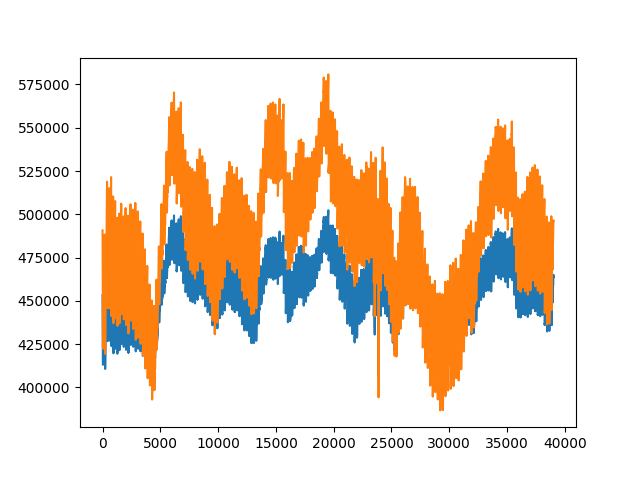

In [4]:
plt.figure()
plt.plot(rd)
plt.plot(ir)

In [ ]:
temp_rd = []
temp_ir = []
plot_indices = [1]

for i in range(len(rd)):
    if (i % 20) == 0:
        temp_rd.append(rd[i])
        temp_ir.append(ir[i])

# Make array sizes divisible by 100 (original size was 1951)
temp_rd = temp_rd[:1900]
temp_ir = temp_ir[:1900]

# Split signal into 100-size chunks
rd_buffs = np.split(np.asarray(temp_rd), 19)
ir_buffs = np.split(np.asarray(temp_ir), 19)

## SpO2 Calculation Algorithm

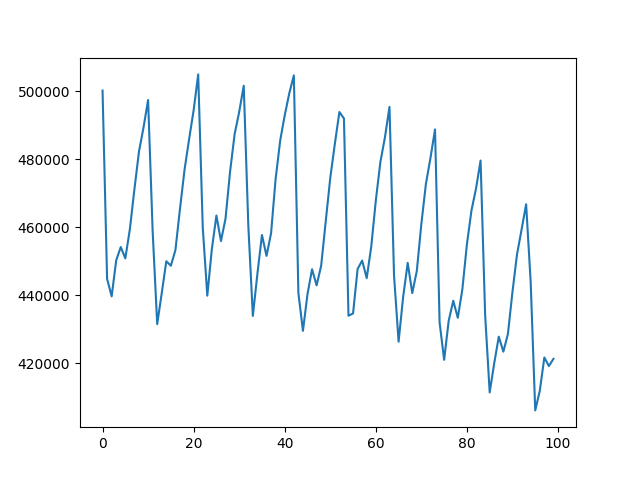

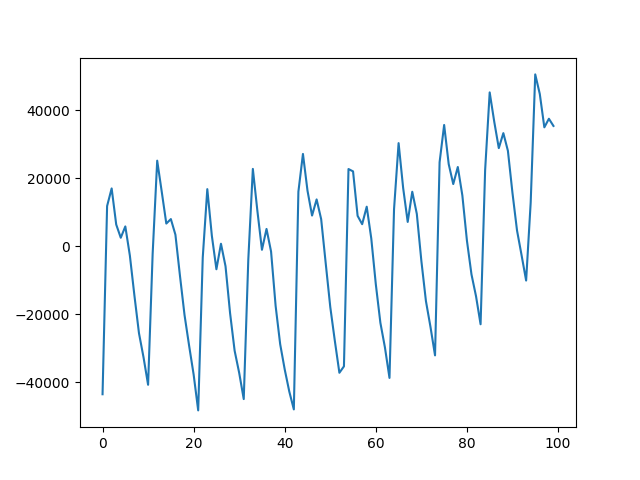

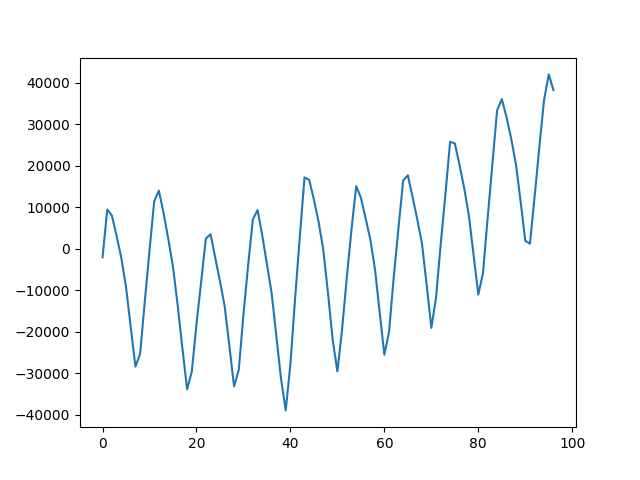

In [ ]:
for i in range(len(ir_buffs)):
    rd_buff = rd_buffs[i]
    ir_buff = ir_buffs[i]

    # Plot of original signal
    if i in plot_indices:
        plt.figure()
        plt.plot(ir_buff)

    # Remove DC and invert signal so that we can use peak detector as valley detector
    ir_mean = np.sum(ir_buff) / len(ir_buff)
    an_x = -1 * (ir_buff - ir_mean)

    # Plot of signal after removing DC component and inverting
    if i in plot_indices:
        plt.figure()
        plt.plot(an_x)

    # Apply 4-point moving average
    window = np.ones(4) / 4
    an_x = np.convolve(an_x, window, mode='valid')

    # Plot of signal after applying 4-point moving average
    if i in plot_indices:
        plt.figure()
        plt.plot(an_x)